# SVM on mobile_price.csv

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
DATA_PATH = 'data/mobile_price.csv'

In [2]:
# Load and shuffle data with random seed 42
df = pd.read_csv(DATA_PATH)
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

target_col = 'price_range' if 'price_range' in df.columns else df.columns[-1]
X = df.drop(columns=[target_col]).values
y = df[target_col].values

# Split into train/val/test = 60/20/20
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=SEED, shuffle=True, stratify=y_train_val
)

print('Shapes -> train:', X_train.shape, '| val:', X_val.shape, '| test:', X_test.shape)

Shapes -> train: (1200, 20) | val: (400, 20) | test: (400, 20)


In [3]:
def evaluate_svm_for_c(C_value, X_train, y_train, X_val, y_val, X_test, y_test):
    clf = make_pipeline(StandardScaler(), SVC(C=C_value, random_state=SEED))
    clf.fit(X_train, y_train)

    y_pred_train = clf.predict(X_train)
    y_pred_val = clf.predict(X_val)
    y_pred_test = clf.predict(X_test)

    return {
        'C': C_value,
        'train_accuracy': accuracy_score(y_train, y_pred_train),
        'val_accuracy': accuracy_score(y_val, y_pred_val),
        'test_accuracy': accuracy_score(y_test, y_pred_test),
        'train_f1': f1_score(y_train, y_pred_train, average='weighted'),
        'val_f1': f1_score(y_val, y_pred_val, average='weighted'),
        'test_f1': f1_score(y_test, y_pred_test, average='weighted'),
    }

In [7]:
# 2(a): Train SVM with C=1.0 and report train/val/test metrics
result_c1 = evaluate_svm_for_c(1.0, X_train, y_train, X_val, y_val, X_test, y_test)

print('2(a) - SVM with C=1.0')
print(f"Train    -> Accuracy: {result_c1['train_accuracy']:.4f}, F1-score: {result_c1['train_f1']:.4f}")
print(f"Val      -> Accuracy: {result_c1['val_accuracy']:.4f}, F1-score: {result_c1['val_f1']:.4f}")
print(f"Test     -> Accuracy: {result_c1['test_accuracy']:.4f}, F1-score: {result_c1['test_f1']:.4f}")

2(a) - SVM with C=1.0
Train    -> Accuracy: 0.9842, F1-score: 0.9842
Val      -> Accuracy: 0.8525, F1-score: 0.8530
Test     -> Accuracy: 0.8500, F1-score: 0.8506


In [8]:
# Task 2(b): Explore different C values and evaluate train/val/test metrics
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

results = []
for c in C_values:
    results.append(evaluate_svm_for_c(c, X_train, y_train, X_val, y_val, X_test, y_test))

results_df = pd.DataFrame(results)
display(results_df)

,C,train_accuracy,val_accuracy,test_accuracy,train_f1,val_f1,test_f1
0,0.001,0.800833,0.6975,0.7275,0.805103,0.703923,0.732457
1,0.010,0.800833,0.6975,0.7275,0.805103,0.703923,0.732457
2,0.100,0.800000,0.6950,0.7225,0.804591,0.703485,0.728738
3,1.000,0.984167,0.8525,0.8500,0.984158,0.852973,0.850629
4,10.000,1.000000,0.8550,0.8575,1.000000,0.853795,0.856832
5,100.000,1.000000,0.8550,0.8575,1.000000,0.853795,0.856832
6,1000.000,1.000000,0.8550,0.8575,1.000000,0.853795,0.856832
7,10000.000,1.000000,0.8550,0.8575,1.000000,0.853795,0.856832


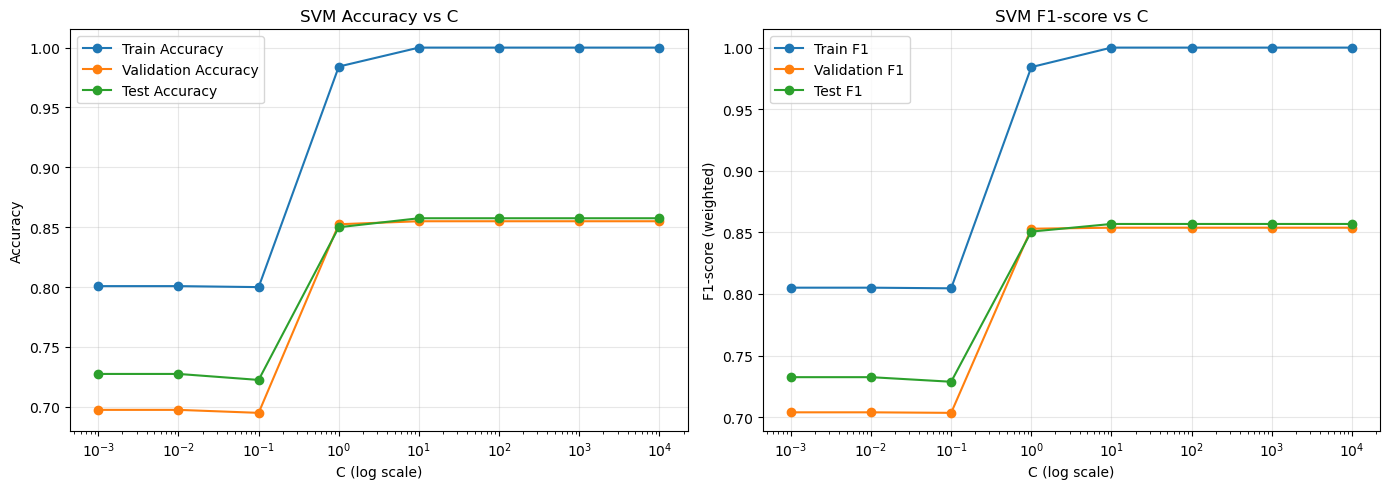

In [9]:
# Visualization of performance vs C
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(results_df['C'], results_df['train_accuracy'], marker='o', label='Train Accuracy')
axes[0].plot(results_df['C'], results_df['val_accuracy'], marker='o', label='Validation Accuracy')
axes[0].plot(results_df['C'], results_df['test_accuracy'], marker='o', label='Test Accuracy')
axes[0].set_xscale('log')
axes[0].set_xlabel('C (log scale)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('SVM Accuracy vs C')
axes[0].grid(alpha=0.3)
axes[0].legend()

# F1-score plot
axes[1].plot(results_df['C'], results_df['train_f1'], marker='o', label='Train F1')
axes[1].plot(results_df['C'], results_df['val_f1'], marker='o', label='Validation F1')
axes[1].plot(results_df['C'], results_df['test_f1'], marker='o', label='Test F1')
axes[1].set_xscale('log')
axes[1].set_xlabel('C (log scale)')
axes[1].set_ylabel('F1-score (weighted)')
axes[1].set_title('SVM F1-score vs C')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()